=== Scenario 4: Stacking ===
LR Accuracy: 0.8333
SVC Accuracy: 0.8056
DT Accuracy: 0.9444
STACKING Accuracy: 0.9444


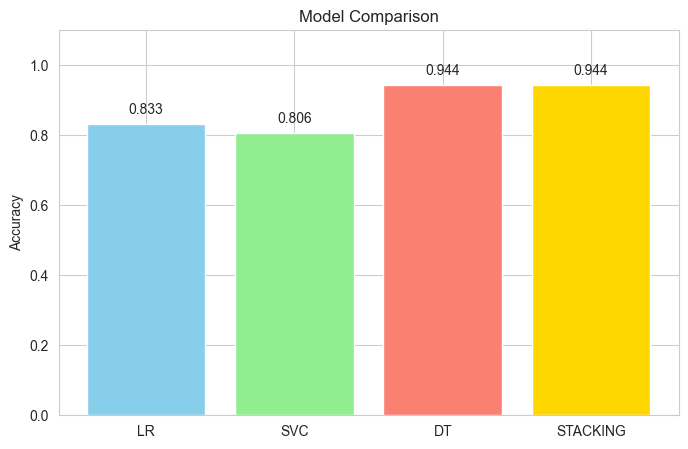

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import StackingClassifier
from sklearn.metrics import accuracy_score

def main():
    # Load Data
    df = pd.read_csv('../dataset/heart_stacking.csv')

    X = df.drop('HeartDisease', axis=1)
    y = df['HeartDisease']

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

    # Define Base Models
    base_models = [
        ('lr', LogisticRegression(max_iter=1000)),
        ('svc', SVC(probability=True)),
        ('dt', DecisionTreeClassifier(max_depth=5, random_state=42))
    ]

    print("=== Scenario 4: Stacking ===")

    model_names = []
    model_accuracies = []

    # Train Individual Models
    for name, model in base_models:
        model.fit(X_train, y_train)
        pred = model.predict(X_test)
        acc = accuracy_score(y_test, pred)
        model_names.append(name.upper())
        model_accuracies.append(acc)
        print(f"{name.upper()} Accuracy: {acc:.4f}")

    # Train Stacking Classifier
    stack_model = StackingClassifier(estimators=base_models, final_estimator=LogisticRegression())
    stack_model.fit(X_train, y_train)
    stack_pred = stack_model.predict(X_test)
    stack_acc = accuracy_score(y_test, stack_pred)

    print(f"STACKING Accuracy: {stack_acc:.4f}")

    model_names.append('STACKING')
    model_accuracies.append(stack_acc)

    # Visualization
    plt.figure(figsize=(8, 5))
    bars = plt.bar(model_names, model_accuracies, color=['skyblue', 'lightgreen', 'salmon', 'gold'])
    plt.title('Model Comparison')
    plt.ylabel('Accuracy')
    plt.ylim(0, 1.1)

    # Add values on top of bars
    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, yval + 0.02, f'{yval:.3f}', ha='center', va='bottom')

    plt.show()

if __name__ == '__main__':
    main()
